### 타이타닉 데이터세트 로딩하기

In [1]:
import pandas as pd

titanic_df = pd.read_csv('titanic_train.csv')
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Histogram
* 연속값에 대한 구간별 도수 분포를 시각화

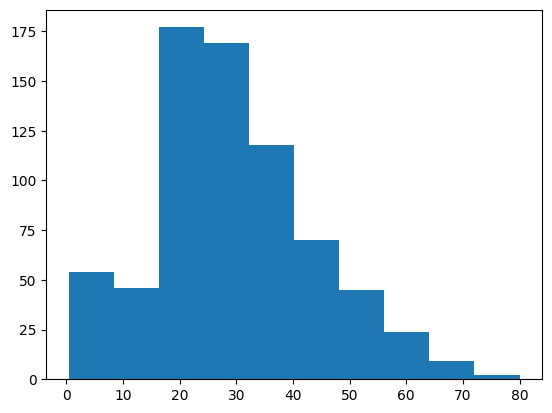

In [2]:
### matplotlib histogram
import matplotlib.pyplot as plt

plt.hist(titanic_df['Age'])
plt.show()

<Axes: >

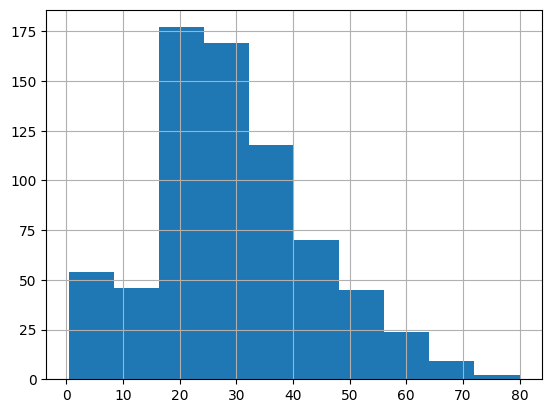

In [3]:
# Pandas에서도 hist 함수 호출 가능
titanic_df['Age'].hist()

### seaborn histogram
* seaborn의 예전 histogram은 distplot함수지만 deprecate됨.
* seaborn의 histogram은 histplot과 displot이 대표적이며 histplot은 axes레벨, displot은 figure레벨임.

<Axes: xlabel='Age', ylabel='Density'>

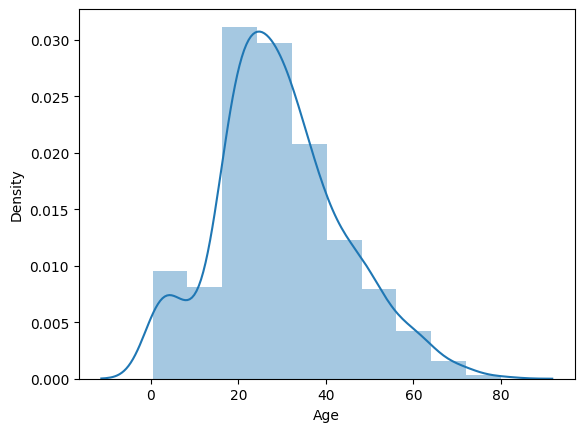

In [4]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.distplot(titanic_df['Age'], bins=10)

<Axes: xlabel='Age', ylabel='Count'>

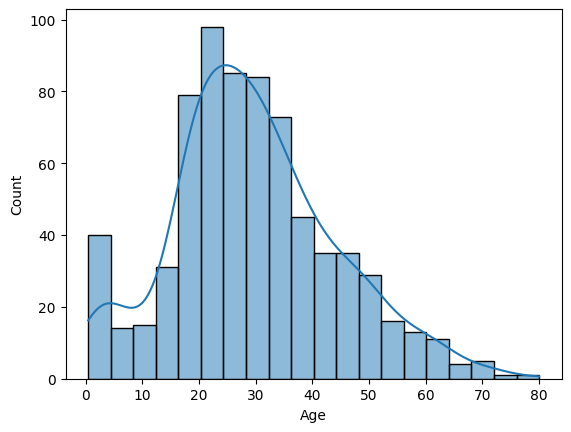

In [5]:
sns.histplot(titanic_df['Age'], kde=True)

<Axes: xlabel='Age', ylabel='Count'>

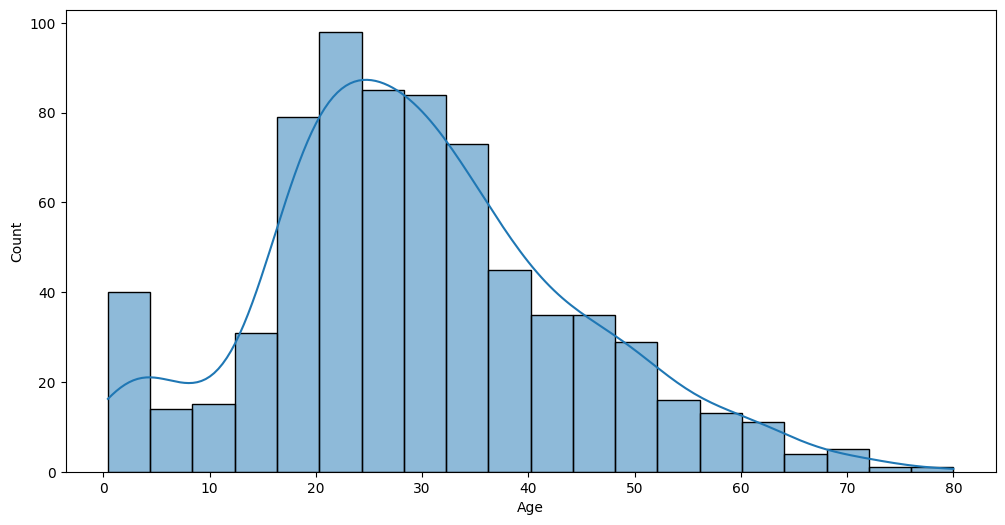

In [6]:
plt.figure(figsize=(12,6))
sns.histplot(titanic_df['Age'], kde=True)

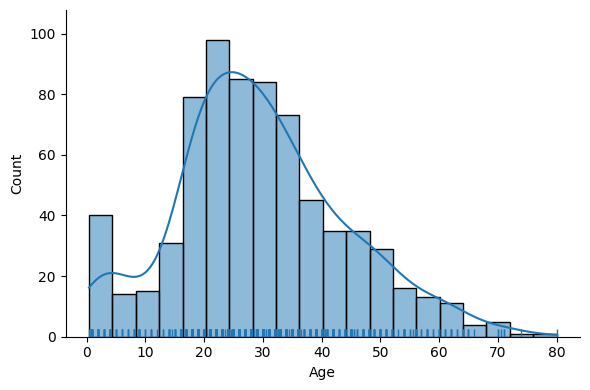

In [7]:
# seaborn의 figure레벨 그래프는 plt.figure로 figure 크기를 조절할 수 없습니다.
sns.displot(titanic_df['Age'], kde=True, rug=True, height=4, aspect=1.5)

<Axes: xlabel='Age', ylabel='Density'>

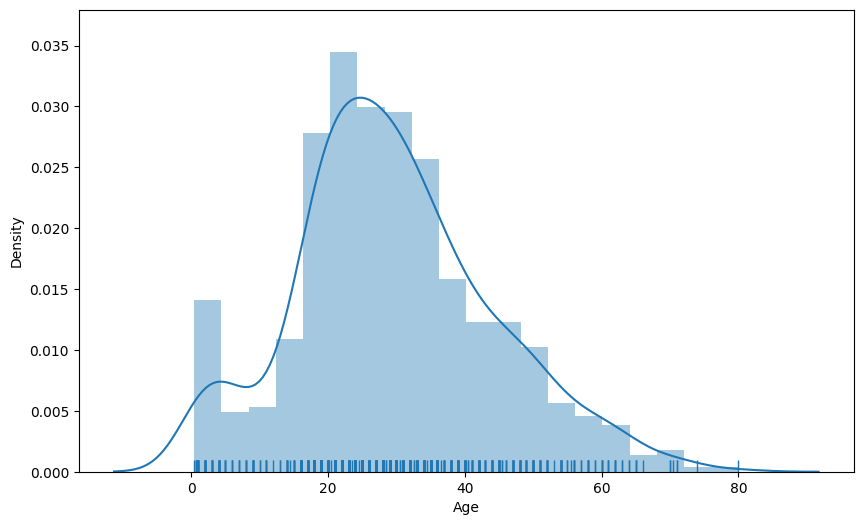

In [8]:
plt.figure(figsize=(10, 6))
sns.distplot(titanic_df['Age'], kde=True, rug=True)

### seaborn의 countplot은 카테고리 값에 대한 건수를 표현. x축이 카테고리값, y축이 해당 카테고리값에 대한 건수

<Axes: xlabel='Pclass', ylabel='count'>

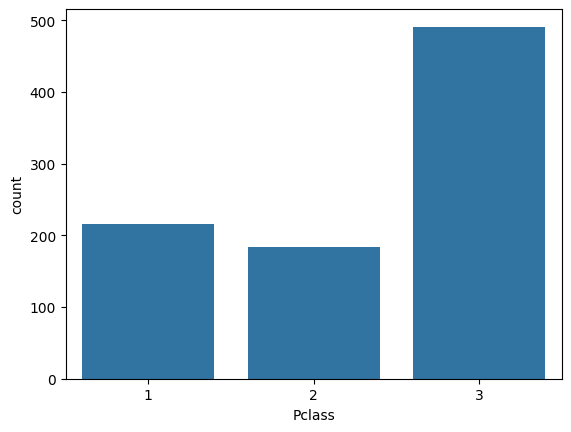

In [9]:
sns.countplot(x='Pclass', data=titanic_df)

### barplot
seaborn의 barplot은 x축은 이산값(주로 category값), y축은 연속값(y값의 평균/총합)을 표현

<Axes: xlabel='Pclass', ylabel='Age'>

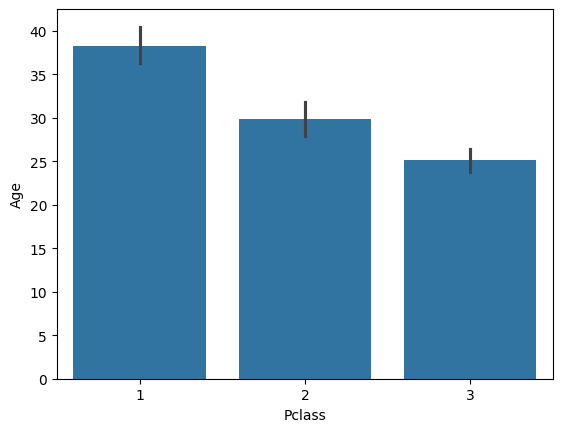

In [10]:
sns.barplot(x='Pclass', y='Age', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

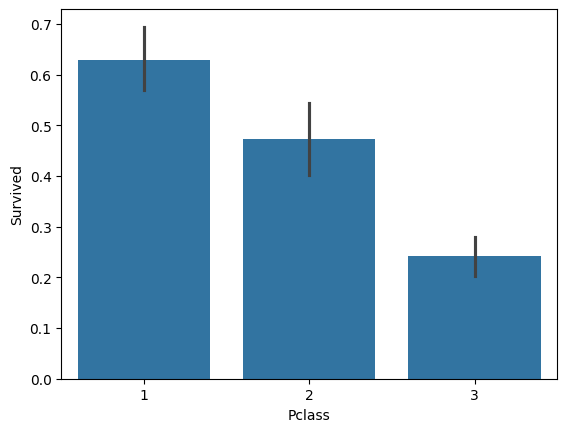

In [11]:
sns.barplot(x='Pclass', y='Survived', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Sex'>

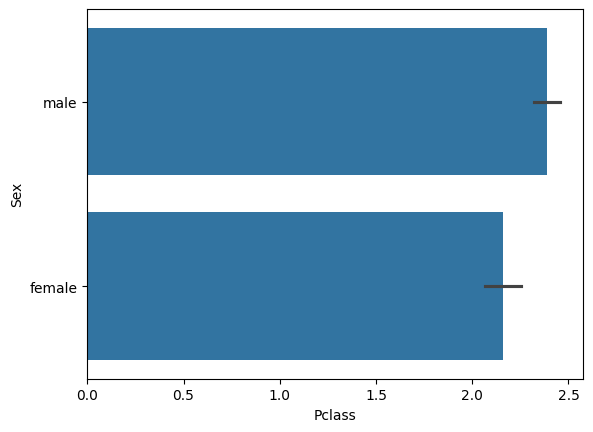

In [12]:
sns.barplot(x='Pclass', y='Sex', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

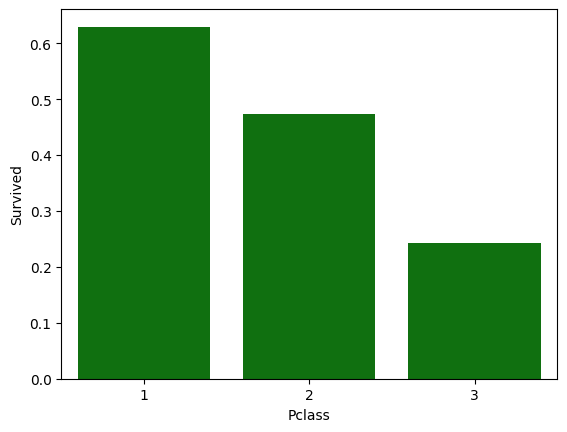

In [13]:
sns.barplot(x='Pclass', y='Survived', data=titanic_df, ci=None, color='green')

<Axes: xlabel='Pclass', ylabel='Survived'>

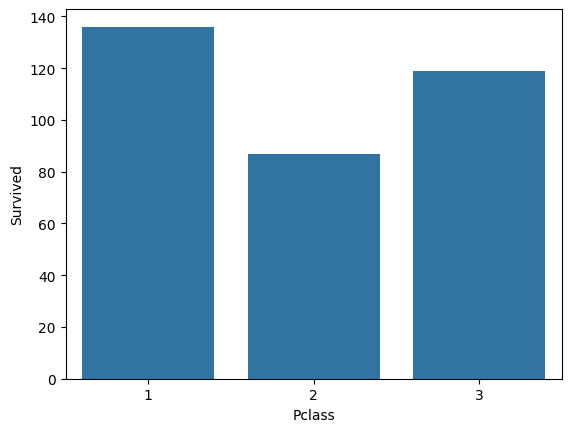

In [14]:
# 평균이 아니라 총합으로 표현
sns.barplot(x='Pclass', y='Survived', data=titanic_df, ci=None, estimator=sum)

### bar plot에서 hue를 이용하여 X값을 특정 컬럼별로 세분화하여 시각화

<Axes: xlabel='Pclass', ylabel='Age'>

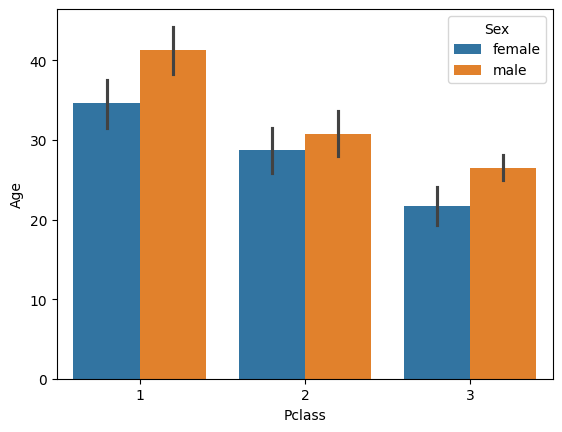

In [15]:
sns.barplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)

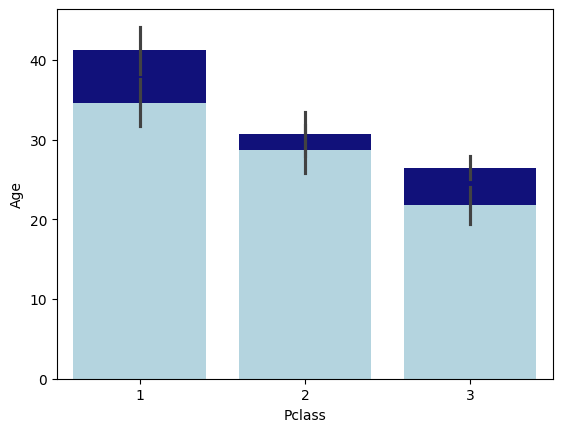

In [16]:
bar1 = sns.barplot(x="Pclass",  y="Age", data=titanic_df[titanic_df['Sex']=='male'], color='darkblue')
bar2 = sns.barplot(x="Pclass",  y="Age", data=titanic_df[titanic_df['Sex']=='female'], color='lightblue')

<Axes: xlabel='Pclass', ylabel='Survived'>

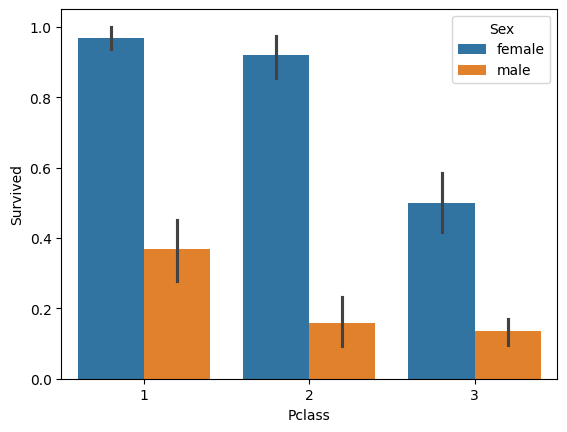

In [17]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)

In [18]:
# 나이에 따라 세분화된 분류를 수행하는 함수 생성.
def get_category(age):
    cat = ''
    if age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else : cat = 'Elderly'

    return cat

# lambda 식에 위에서 생성한 get_category( ) 함수를 반환값으로 지정.
# get_category(X)는 입력값으로 ‘Age’ 칼럼 값을 받아서 해당하는 cat 반환
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x : get_category(x))

<Axes: xlabel='Age_cat', ylabel='Survived'>

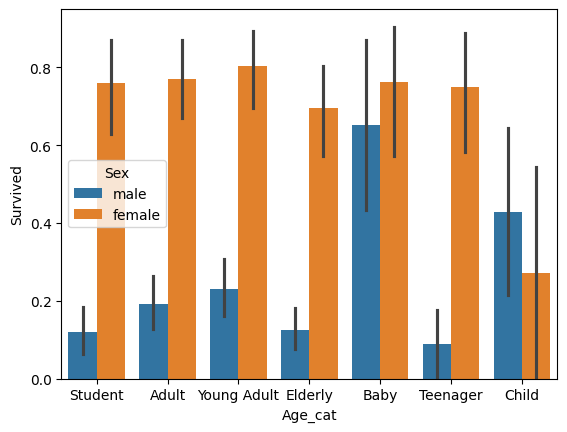

In [19]:
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df)

<Axes: xlabel='Age_cat', ylabel='Survived'>

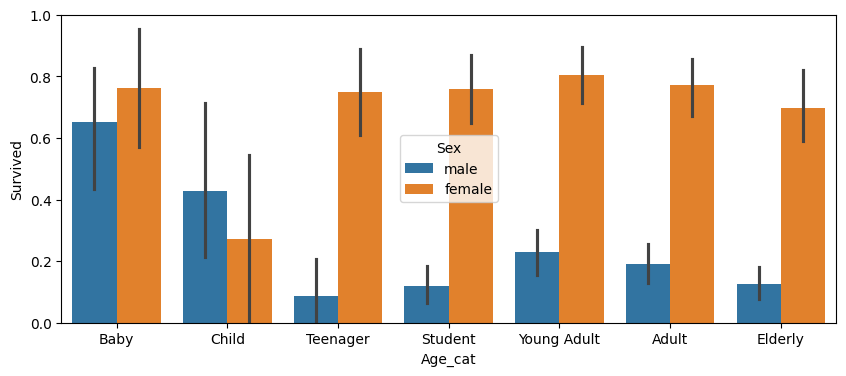

In [20]:
plt.figure(figsize=(10,4))
order_columns = ['Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=order_columns)

<Axes: xlabel='Sex', ylabel='Survived'>

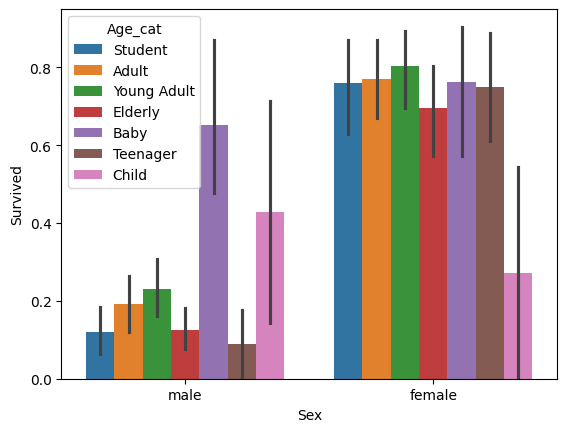

In [21]:
sns.barplot(x='Sex', y='Survived', hue='Age_cat', data=titanic_df)

<Axes: xlabel='Survived', ylabel='Pclass'>

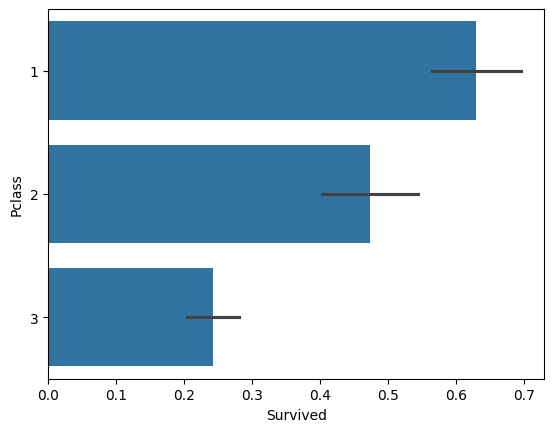

In [22]:
# orient를 h를 하면 수평 바 플롯을 그림. 단 이번엔 y축값이 이산형 값
sns.barplot(x='Survived', y='Pclass', data=titanic_df, orient='h')

### violin plot
* 단일 컬럼에 대해서는 히스토그램과 유사하게 연속값의 분포도를 시각화. 또한 중심에는 4분위를 알수있음.
* 보통은 X축에 설정한 컬럼의 개별 이산값 별로 Y축 컬럼값의 분포도를 시각화하는 용도로 많이 사용

<Axes: ylabel='Age'>

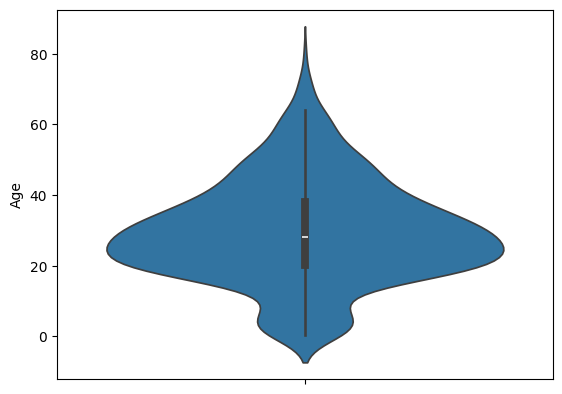

In [23]:
# Age 컬럼에 대한 연속 확률 분포 시각화
sns.violinplot(y='Age', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Age'>

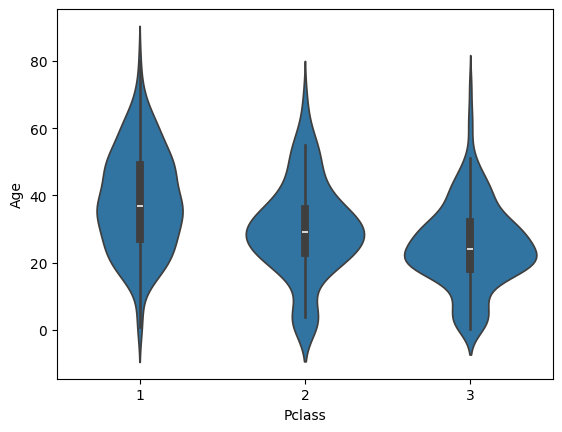

In [24]:
sns.violinplot(x='Pclass', y='Age', data=titanic_df)

<Axes: xlabel='Sex', ylabel='Age'>

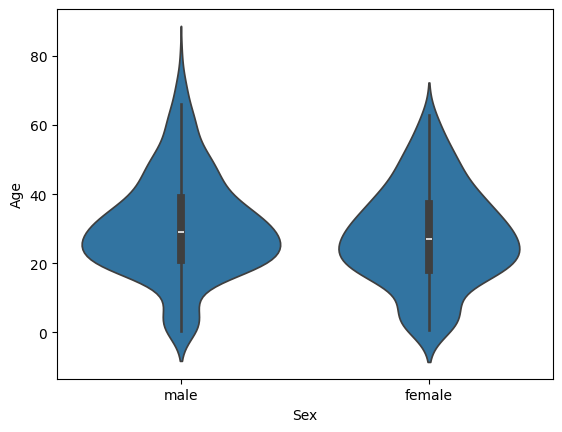

In [25]:
sns.violinplot(x='Sex', y='Age', data=titanic_df)

### seaborn에서 subplots 이용하기

### subplots을 이용하여 주요 category성 컬럼의 건수를 시각화 하기

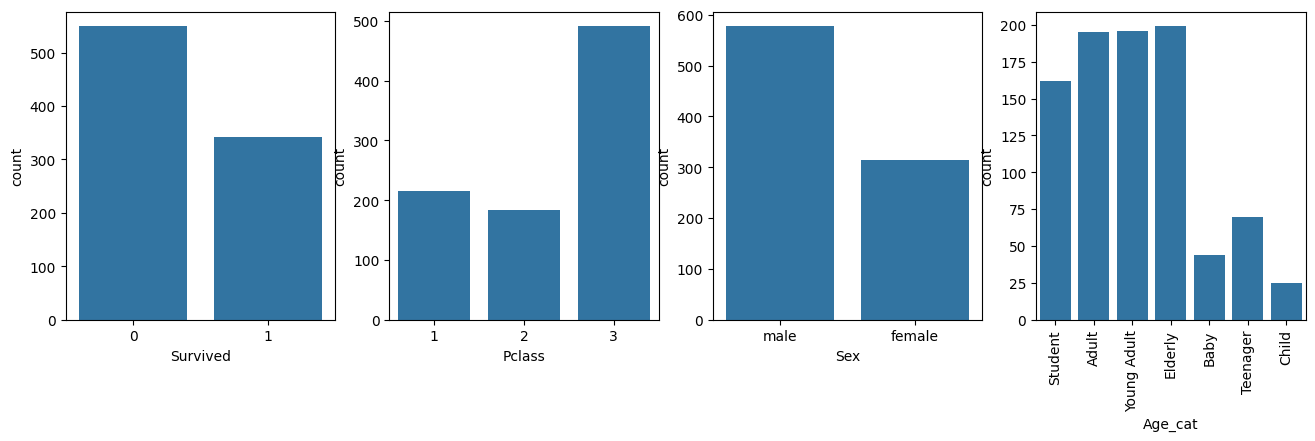

In [26]:
cat_columns = ['Survived', 'Pclass', 'Sex', 'Age_cat']

# nrows는 1이고 ncols는 컬럼의 갯수만큼인 subplots을 설정.
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(16, 4))

for index, column in enumerate(cat_columns):
    # seaborn의 Axes 레벨 function들은 ax인자로 subplots의 어느 Axes에 위치할지 설정.
    sns.countplot(x=column, data=titanic_df, ax=axs[index])
    if index == 3:
        # plt.xticks(rotation=90)으로 간단하게 할수 있지만 Axes 객체를 직접 이용할 경우 API가 상대적으로 복잡.
        axs[index].set_xticklabels(axs[index].get_xticklabels(), rotation=90)


### subplots을 이용하여 주요 category성 컬럼별로 컬럼값에 따른 생존율 시각화 하기

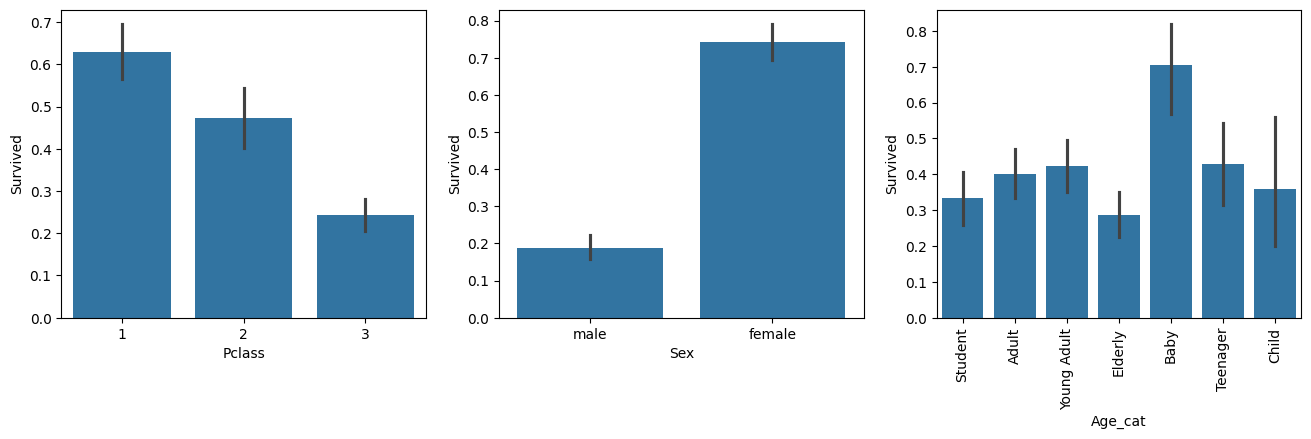

In [27]:
cat_columns = ['Pclass', 'Sex', 'Age_cat']
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(16, 4))

for index, column in enumerate(cat_columns):
    sns.barplot(x=column, y='Survived', data=titanic_df, ax=axs[index])
    if index == 2:
        axs[index].set_xticklabels(axs[index].get_xticklabels(), rotation=90)

### subplots를 이용하여 여러 연속형 컬럼값들의 Survived 값에 따른 연속 분포도를 시각화
* 왼쪽에는 Violin Plot으로
* 오른쪽에는 Survived가 0일때의 Histogram과 Survived가 1일때의 Histogram을 함께 표현

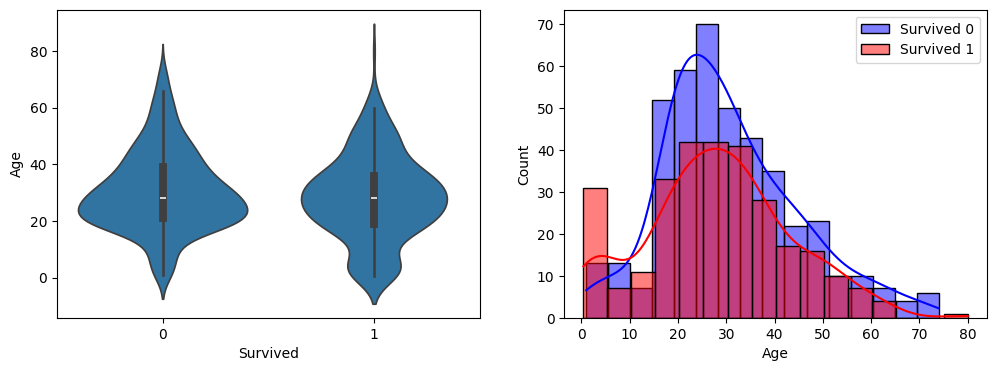

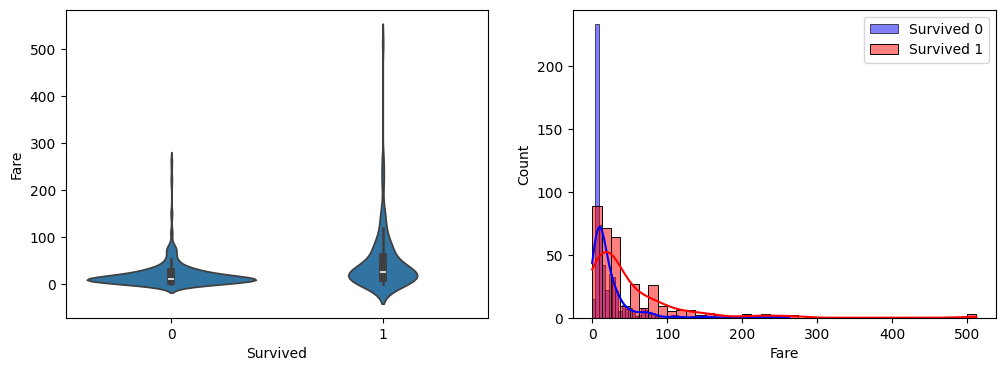

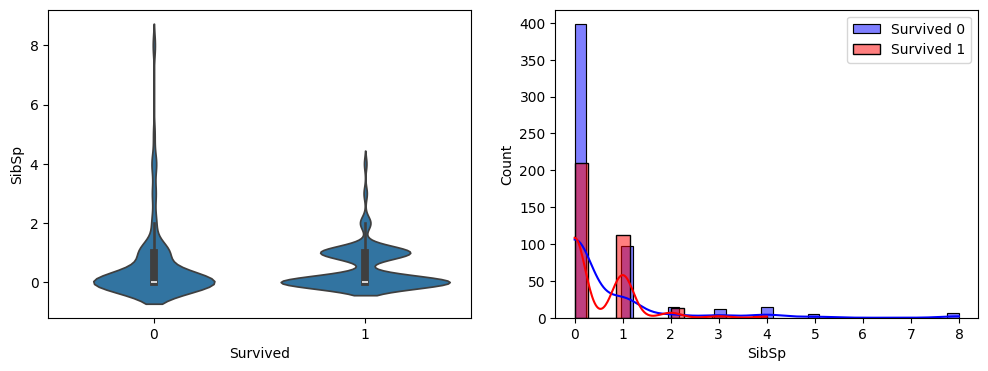

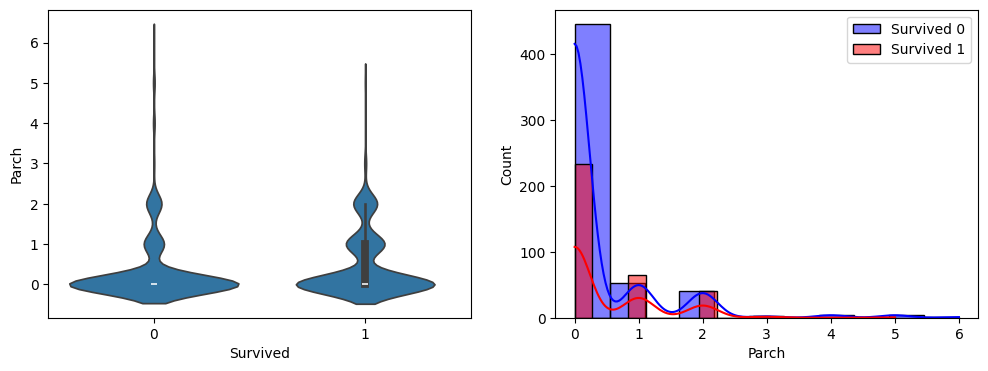

In [28]:
def show_hist_by_target(df, columns):
    cond_1 = (df['Survived']==1)
    cond_0 = (df['Survived']==0)

    for column in columns:
        fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
        sns.violinplot(x='Survived', y=column, data=df, ax=axs[0])
        sns.histplot(df[cond_0][column], ax=axs[1], kde=True, label='Survived 0', color='blue')
        sns.histplot(df[cond_1][column], ax=axs[1], kde=True, label='Survived 1', color='red')
        axs[1].legend()

cont_columns = ['Age', 'Fare', 'SibSp', 'Parch']
show_hist_by_target(titanic_df, cont_columns)

### box plot
* 4분위를 박스 형태로 표현
* x축값에 이산값을 부여하면 이산값에 따른 box plot을 시각화

<Axes: ylabel='Age'>

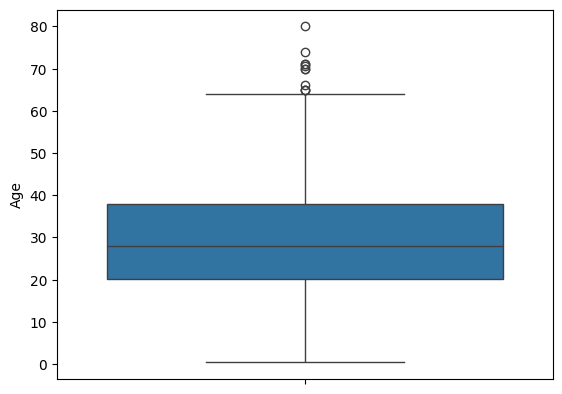

In [29]:
sns.boxplot(y='Age', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Age'>

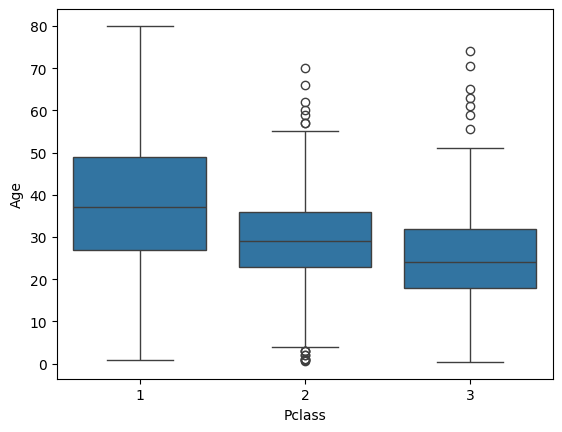

In [30]:
sns.boxplot(x='Pclass', y='Age', data=titanic_df)

### scatter plot
* 산포도로서 X와 Y축에 보통 연속형 값을 시각화. hue, style등을 통해 breakdown 정보를 표출할 수 있습니다.

<Axes: xlabel='Age', ylabel='Fare'>

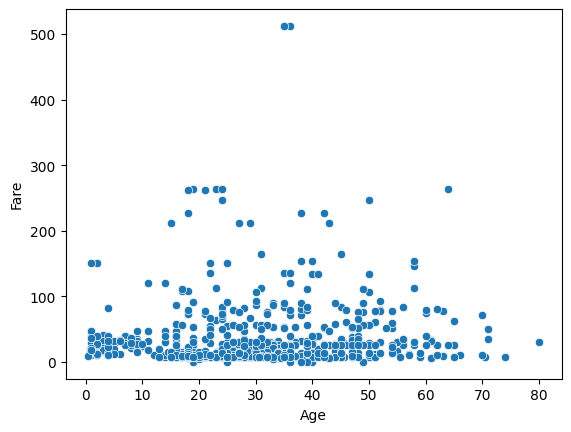

In [31]:
sns.scatterplot(x='Age', y='Fare', data=titanic_df)

<Axes: xlabel='Age', ylabel='Fare'>

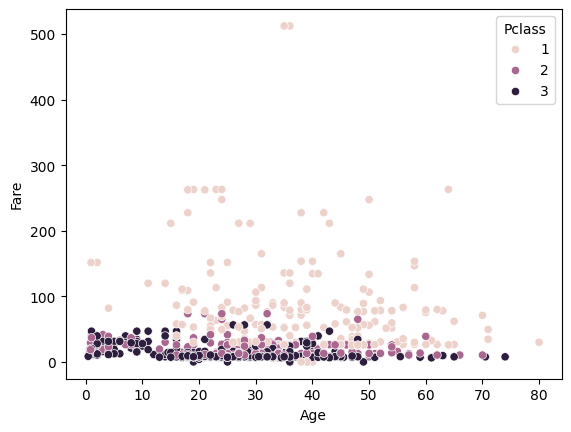

In [32]:
sns.scatterplot(x='Age', y='Fare', data=titanic_df, hue='Pclass')

### 상관 Heatmap
* 컬럼간의 상관도를 Heatmap형태로 표현

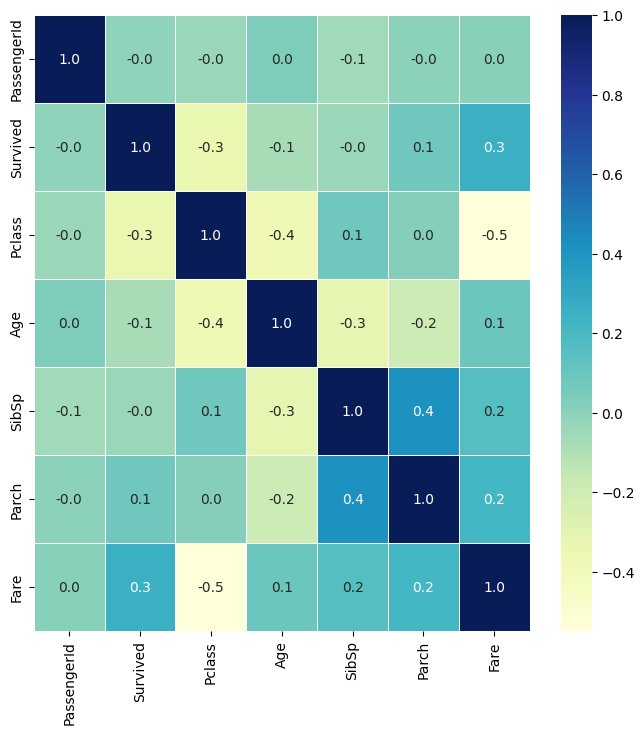

In [33]:
plt.figure(figsize=(8,8))

corr = titanic_df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt='.1f', linewidths=0.5, cmap='YlGnBu')

plt.show()